# Goofy Phase 8 — Paper Trading Framework

**What this phase adds:**  
Phase 7 tells you *which* assets to trade and *when* conditions are favourable.  
Phase 8 tracks whether it was actually right — by logging every TRADE signal at today's price and checking what happened 20 trading days later.

**The logic:**
- Every time Phase 7 fires a TRADE signal, we record the asset + entry price in a persistent JSON log
- After 20 trading days (= LOOKFORWARD, the same window the ML model was trained on), we close the position and record the P&L
- Over time, this builds a track record: does the screener actually pick assets that go up?

**Why paper trading before real trading:**  
No model survives contact with reality unchanged. Paper trading shows you where the system leaks *before* real money is at stake.

---
**Files:**
- `paper_trader.py` — persistent log module  
- `goofy_screener_phase8.py` — full script (run this weekly)  
- `paper_trades/trades_log.json` — the trade journal

In [1]:
# ── Part 1: Imports ──────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf

from paper_trader import (
    get_open_positions, get_closed_trades, get_performance,
    HOLD_DAYS, TRADES_FILE
)
from ml_signal import (
    engineer_features, build_ml_model, get_current_score,
    ml_gate, ML_PASS_THRESH, LOOKFORWARD
)
from goofy_screener_phase5 import TRAIN_END

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)

print('✅ Imports OK')
print(f'📁 Trade log: {TRADES_FILE}')

✅ Imports OK
📁 Trade log: /Users/hiro/quant-research/Claude project (me learning)/Quant python learning 1/paper_trades/trades_log.json


## Part 2 — Open Positions

These are the TRADE signals currently being tracked.  
Each will close automatically after 20 trading days and record its P&L.

In [2]:
# ── Part 2: Open positions ────────────────────────────────────────────────────
open_df = get_open_positions()

if open_df.empty:
    print('📋 No open positions yet.')
    print('   Run goofy_screener_phase8.py first to log today\'s TRADE signals.')
else:
    print(f'📋 {len(open_df)} open position(s)\n')

    display_cols = ['asset', 'market', 'entry_date', 'entry_price', 'current_price',
                    'unrealised_pnl_pct', 'days_held', 'hold_days_target',
                    'size_pct', 'ml_score', 'tier']
    display_cols = [c for c in display_cols if c in open_df.columns]

    styled = open_df[display_cols].copy()
    styled.columns = [c.replace('_', ' ').title() for c in styled.columns]
    display(styled.set_index('Asset'))

    # Progress bar per position
    if 'days_held' in open_df.columns and 'hold_days_target' in open_df.columns:
        print('\n  Hold progress:')
        for _, r in open_df.iterrows():
            days   = r.get('days_held', 0) or 0
            target = r.get('hold_days_target', HOLD_DAYS)
            pct    = min(days / target, 1.0)
            bar    = '█' * int(pct * 20) + '░' * (20 - int(pct * 20))
            pnl    = r.get('unrealised_pnl_pct')
            pnl_s  = f'{pnl:+.2f}%' if pnl is not None else '—'
            print(f"  {r['asset']:14} [{bar}] {days:2}/{target}d  {pnl_s}")

📋 16 open position(s)



,Market,Entry Date,Entry Price,Hold Days Target,Size Pct,Ml Score,Tier
Asset,,,,,,,
AAPL,US,2026-05-12,292.290,20,0.800,77.900,A
TSLA,US,2026-05-12,417.547,20,2.400,72.400,B
PEP,US,2026-05-12,151.865,20,1.500,61.500,B
CAT,US,2026-05-12,897.330,20,1.400,73.000,A
RTX,US,2026-05-12,178.095,20,0.900,90.200,B
IWM,US,2026-05-12,286.160,20,0.600,72.900,B
CBA.AX,ASX,2026-05-12,174.010,20,6.800,80.000,S
ANZ.AX,ASX,2026-05-12,35.900,20,1.600,65.100,A
FMG.AX,ASX,2026-05-12,21.420,20,3.000,74.800,B


## Part 3 — Closed Trade Performance

Positions that have been held for 20 trading days are closed and recorded here.  
On Day 1 this will be empty — that's expected.

In [3]:
# ── Part 3: Closed trades + performance ──────────────────────────────────────
closed_df = get_closed_trades()
perf      = get_performance()

if closed_df.empty:
    print('📈 No closed trades yet.')
    print(f'   Positions logged today will close in ≈{HOLD_DAYS} trading days.')
    print('   Come back then to see actual P&L.')
else:
    print(f'📈 {perf["n_closed"]} closed trade(s)\n')

    # Summary
    print(f'  Win rate          : {perf["win_rate"]:.1%}')
    print(f'  Avg P&L per trade : {perf["avg_pnl_pct"]:+.2f}%')
    print(f'  Median P&L        : {perf["median_pnl_pct"]:+.2f}%')
    print(f'  Std dev           : {perf["std_pnl_pct"]:.2f}%')
    if perf.get('annualised_sharpe'):
        print(f'  Annualised Sharpe : {perf["annualised_sharpe"]:.2f}')
    print(f'  Best  : {perf["best_trade"]["asset"]}  {perf["best_trade"]["pnl_pct"]:+.2f}%')
    print(f'  Worst : {perf["worst_trade"]["asset"]}  {perf["worst_trade"]["pnl_pct"]:+.2f}%')

    display_cols = ['asset', 'market', 'entry_date', 'entry_price',
                    'exit_date', 'exit_price', 'pnl_pct', 'win', 'tier']
    display_cols = [c for c in display_cols if c in closed_df.columns]
    display(closed_df[display_cols].sort_values('exit_date', ascending=False).set_index('asset'))

📈 No closed trades yet.
   Positions logged today will close in ≈20 trading days.
   Come back then to see actual P&L.


## Part 4 — Historical Signal Simulation

Since we just started the paper trader today, there's no live track record yet.  
But we can look back and ask: **if we'd been running Phase 7 over the past two years, what would have happened?**

For each current TRADE asset, we:
1. Download price history
2. Re-run the ML model on the test period (2021–present)
3. Find every date where ML score ≥ 55% (PASS gate)
4. Compute the actual 20-day forward return at each signal date

This is a **historical validation** — we already know the prices, so it's not a true forward test.  
But it tells us: did the ML signal actually correlate with good 20-day returns in the test period?

In [4]:
# ── Part 4: Historical simulation ────────────────────────────────────────────
if open_df.empty:
    sim_assets = ['CBA.AX', 'STW.AX', 'CAT', 'PEP', 'IWM']
else:
    sim_assets = (open_df.sort_values('score', ascending=False)['asset'].head(6).tolist()
                  if 'score' in open_df.columns else open_df['asset'].head(6).tolist())

print(f"Simulating {len(sim_assets)} assets: {sim_assets}")
print()

train_end_str = TRAIN_END.strftime('%Y-%m-%d')
sim_results   = []

for asset in sim_assets:
    try:
        raw = yf.download(asset, start='2016-01-01', progress=False, auto_adjust=True)
        if raw.empty or len(raw) < 400:
            print(f"  x {asset} -- not enough data")
            continue
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        price = raw['Close'].squeeze()
        ohlc  = raw[['High', 'Low', 'Close']].copy() if {'High', 'Low', 'Close'}.issubset(raw.columns) else None

        # Train model (with OHLC so atr_pct feature is included)
        model, feat_names, train_auc, val_auc = build_ml_model(
            price, ohlc, train_end=train_end_str
        )
        if model is None:
            print(f"  x {asset} -- model failed")
            continue

        # Engineer features for TEST period (pass ohlc to get atr_pct)
        features = engineer_features(price, ohlc)
        test_features = features[features.index >= pd.Timestamp(train_end_str)]
        if test_features.empty:
            continue

        # Score every day in the test period
        avail = [f for f in feat_names if f in test_features.columns]
        scores = model.predict_proba(test_features[avail])[:, 1]
        score_series = pd.Series(scores, index=test_features.index)

        # 20-day forward return at each date (known -- historical validation)
        fwd_ret = price.pct_change(LOOKFORWARD).shift(-LOOKFORWARD) * 100

        # Only keep dates where ML score crosses the PASS threshold
        signal_mask  = score_series >= ML_PASS_THRESH
        signal_dates = score_series[signal_mask].index

        for d in signal_dates:
            fwd = fwd_ret.get(d)
            if fwd is not None and not np.isnan(fwd):
                sim_results.append({
                    'asset':       asset,
                    'date':        d,
                    'ml_score':    round(float(score_series[d]) * 100, 1),
                    'fwd_20d_ret': round(float(fwd), 3),
                })

        auc_s = f'{val_auc:.3f}' if val_auc is not None else 'n/a'
        print(f"  ok {asset:14} | Val AUC={auc_s} | PASS signals: {signal_mask.sum()} / {len(score_series)}")

    except Exception as e:
        print(f"  x {asset} -- {e}")

sim_df = pd.DataFrame(sim_results)
print()
print(f"Total signal observations: {len(sim_df)}")

Simulating 6 assets: ['TSLA', 'CAT', 'CBA.AX', 'AAPL', 'WDS.AX', 'STW.AX']



  ok TSLA           | Val AUC=0.470 | PASS signals: 1114 / 1344


  ok CAT            | Val AUC=0.588 | PASS signals: 908 / 1344


  ok CBA.AX         | Val AUC=0.423 | PASS signals: 563 / 1353


  ok AAPL           | Val AUC=0.514 | PASS signals: 1177 / 1344


  ok WDS.AX         | Val AUC=0.467 | PASS signals: 813 / 1353


  ok STW.AX         | Val AUC=0.516 | PASS signals: 926 / 1352

Total signal observations: 5387


## Part 5 — P&L Distribution: PASS signals vs All days

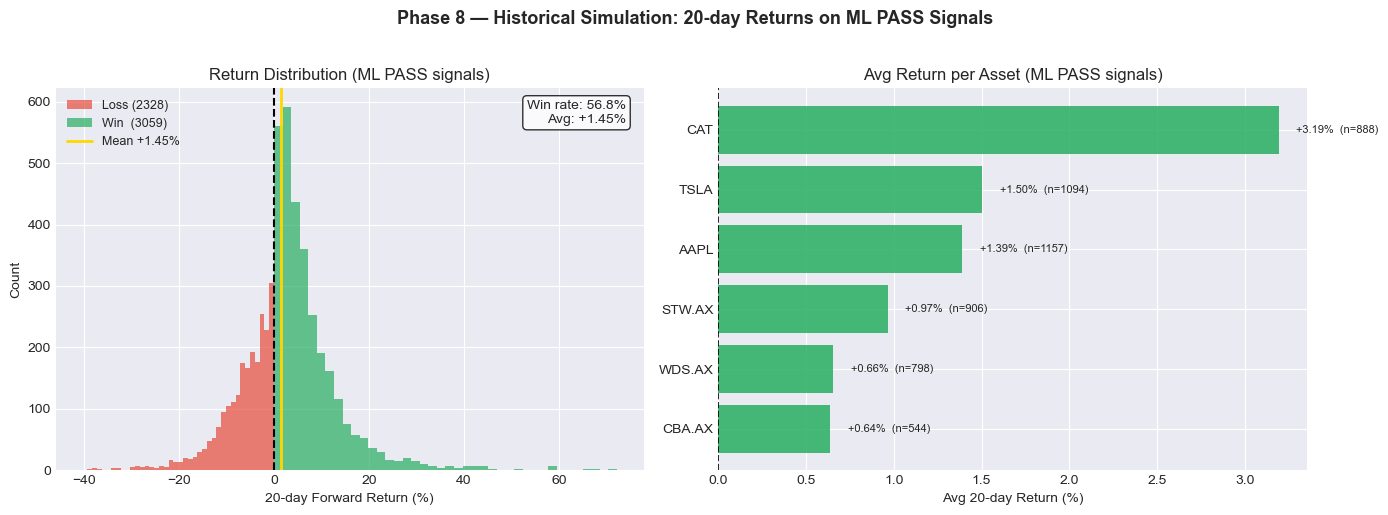


Overall (all assets combined):
  Observations : 5387
  Win rate     : 56.8%
  Avg return   : +1.45%
  Median return: +1.19%


In [5]:
# ── Part 5: P&L distribution ─────────────────────────────────────────────────
if sim_df.empty:
    print('No simulation data — check asset downloads above.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Phase 8 — Historical Simulation: 20-day Returns on ML PASS Signals',
                 fontsize=13, fontweight='bold', y=1.02)

    # ── Left: P&L distribution ────────────────────────────────────────────────
    ax = axes[0]
    wins  = sim_df[sim_df['fwd_20d_ret'] > 0]['fwd_20d_ret']
    losses= sim_df[sim_df['fwd_20d_ret'] <= 0]['fwd_20d_ret']

    ax.hist(losses, bins=40, color='#E74C3C', alpha=0.7, label=f'Loss ({len(losses)})')
    ax.hist(wins,   bins=40, color='#27AE60', alpha=0.7, label=f'Win  ({len(wins)})')
    ax.axvline(0,                               color='black', lw=1.5, ls='--')
    ax.axvline(sim_df['fwd_20d_ret'].mean(),    color='gold',  lw=2,   ls='-',
               label=f'Mean {sim_df["fwd_20d_ret"].mean():+.2f}%')
    ax.set_xlabel('20-day Forward Return (%)')
    ax.set_ylabel('Count')
    ax.set_title('Return Distribution (ML PASS signals)')
    ax.legend(fontsize=9)

    win_rate = (sim_df['fwd_20d_ret'] > 0).mean()
    avg_ret  = sim_df['fwd_20d_ret'].mean()
    ax.text(0.97, 0.97, f'Win rate: {win_rate:.1%}\nAvg: {avg_ret:+.2f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ── Right: Per-asset breakdown ────────────────────────────────────────────
    ax2 = axes[1]
    asset_stats = (sim_df.groupby('asset')['fwd_20d_ret']
                   .agg(['mean', 'count', lambda x: (x > 0).mean()])
                   .rename(columns={'mean': 'avg_ret', 'count': 'n', '<lambda_0>': 'win_rate'})
                   .sort_values('avg_ret', ascending=True))

    colours = ['#27AE60' if v >= 0 else '#E74C3C' for v in asset_stats['avg_ret']]
    bars = ax2.barh(asset_stats.index, asset_stats['avg_ret'], color=colours, alpha=0.85)
    ax2.axvline(0, color='black', lw=1.2, ls='--')
    for bar, (asset, row) in zip(bars, asset_stats.iterrows()):
        x = bar.get_width()
        ax2.text(x + (0.1 if x >= 0 else -0.1),
                 bar.get_y() + bar.get_height() / 2,
                 f'{row["avg_ret"]:+.2f}%  (n={int(row["n"])})',
                 va='center', ha='left' if x >= 0 else 'right', fontsize=8)
    ax2.set_xlabel('Avg 20-day Return (%)')
    ax2.set_title('Avg Return per Asset (ML PASS signals)')

    plt.tight_layout()
    plt.show()

    print(f'\nOverall (all assets combined):')
    print(f'  Observations : {len(sim_df)}')
    print(f'  Win rate     : {win_rate:.1%}')
    print(f'  Avg return   : {avg_ret:+.2f}%')
    print(f'  Median return: {sim_df["fwd_20d_ret"].median():+.2f}%')

## Part 6 — Cumulative Equity Curve

Simulate a simple equal-weight paper portfolio:  
- On each ML PASS signal date, we "buy" an equal share  
- Hold 20 days, collect the return  
- Average across all assets active on a given month

Compared to SPY buy-and-hold over the same period.

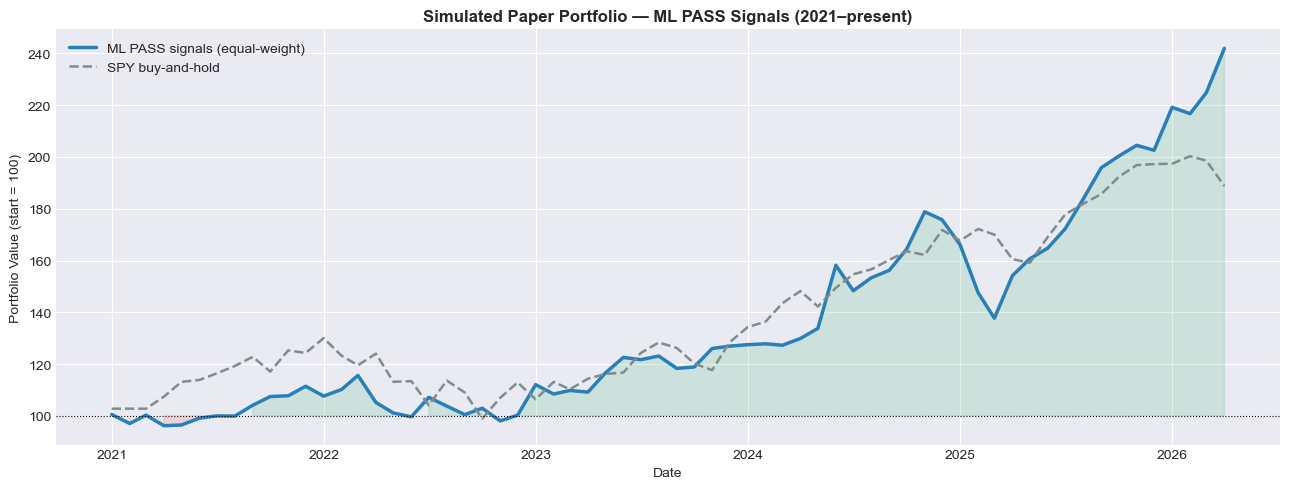


Simulated equity curve:
  Start value : 100
  End value   : 242.0
  Total return: +142.0%
  SPY return  : +88.8%
  Alpha       : +53.2%


In [6]:
# ── Part 6: Cumulative equity curve ──────────────────────────────────────────
if sim_df.empty:
    print('No simulation data.')
else:
    # Resample to monthly: average return for all signals in that month
    sim_df['date'] = pd.to_datetime(sim_df['date'])
    monthly = (sim_df.groupby(sim_df['date'].dt.to_period('M'))['fwd_20d_ret']
               .mean()
               .to_timestamp())

    # Cumulative equity (start at 100)
    equity = (1 + monthly / 100).cumprod() * 100

    # SPY benchmark
    spy_raw = yf.download('SPY', start=str(monthly.index[0].date()),
                          progress=False, auto_adjust=True)
    if not spy_raw.empty:
        if isinstance(spy_raw.columns, pd.MultiIndex):
            spy_raw.columns = spy_raw.columns.get_level_values(0)
        spy_m = (spy_raw['Close'].squeeze()
                 .resample('ME').last()
                 .pct_change()
                 .dropna())
        spy_eq = (1 + spy_m).cumprod() * 100
        spy_eq = spy_eq.reindex(equity.index, method='nearest')
    else:
        spy_eq = None

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(equity.index, equity.values, color='#2980B9', lw=2.5,
            label='ML PASS signals (equal-weight)')
    if spy_eq is not None:
        ax.plot(spy_eq.index, spy_eq.values, color='#7F8C8D', lw=1.8,
                ls='--', label='SPY buy-and-hold')
    ax.axhline(100, color='black', lw=0.8, ls=':')
    ax.fill_between(equity.index, 100, equity.values,
                    where=equity.values >= 100, alpha=0.15, color='#27AE60')
    ax.fill_between(equity.index, 100, equity.values,
                    where=equity.values < 100,  alpha=0.15, color='#E74C3C')
    ax.set_title('Simulated Paper Portfolio — ML PASS Signals (2021–present)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Portfolio Value (start = 100)')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    final_val = equity.iloc[-1]
    total_ret = final_val - 100
    print(f'\nSimulated equity curve:')
    print(f'  Start value : 100')
    print(f'  End value   : {final_val:.1f}')
    print(f'  Total return: {total_ret:+.1f}%')
    if spy_eq is not None and not spy_eq.empty:
        spy_ret = spy_eq.iloc[-1] - 100
        print(f'  SPY return  : {spy_ret:+.1f}%')
        print(f'  Alpha       : {total_ret - spy_ret:+.1f}%')

## Part 7 — What to Watch

### How to interpret these results

| Metric | What's good | What's concerning |
|--------|------------|-------------------|
| Win rate | > 52% consistently | < 45% for more than 20 trades |
| Avg return | > 0% | Negative after 30+ trades |
| Annualised Sharpe | > 0.5 | < 0 |
| ML PASS vs All days | PASS days should outperform | No difference = ML adds nothing |

### Important caveats
1. **The simulation above is NOT out-of-sample** in the strict sense — we used the trained model on the test period, but we looked at prices we already know. The real forward test is the live paper log.
2. **20-day returns are noisy** — 50 trades is a minimum for statistical confidence. At 1–2 signals per week, that's ~6 months.
3. **No transaction costs, no slippage** — real performance will be lower. When you move to live trading, add ≈0.1–0.3% cost per trade.
4. **Currency risk** — JPX/ASX returns in local currency. A falling AUD or JPY affects your actual AUD return.

### Phase 9 (next step)
Once you have 20+ closed trades, the natural next step is:
- Compare TRADE signals vs ML HOLD signals: did filtering actually help?
- Add stop-loss logic (e.g., exit if -5% at any point)
- Connect to a real broker API (e.g., Interactive Brokers) for live execution

In [7]:
# ── Part 7: Summary snapshot ──────────────────────────────────────────────────
open_df   = get_open_positions()
closed_df = get_closed_trades()
perf      = get_performance()

print('═' * 60)
print('  PHASE 8 — PAPER TRADING SNAPSHOT')
print('═' * 60)
print(f'  Open positions : {perf.get("n_open", 0)}')
print(f'  Closed trades  : {perf.get("n_closed", 0)}')

if perf.get('n_closed', 0) > 0:
    print(f'  Win rate       : {perf["win_rate"]:.1%}')
    print(f'  Avg P&L        : {perf["avg_pnl_pct"]:+.2f}%')
    if perf.get('annualised_sharpe'):
        print(f'  Ann. Sharpe    : {perf["annualised_sharpe"]:.2f}')
    print()
    if perf.get('by_tier'):
        print('  By tier:')
        for tier in ['S', 'A', 'B']:
            if tier in perf['by_tier']:
                t = perf['by_tier'][tier]
                icon = {'S': '⭐', 'A': '✅', 'B': '🔵'}.get(tier, '')
                print(f'    {icon} {tier}  n={t["n"]:3}  '
                      f'win={t["win_rate"]:.0%}  avg={t["avg_pnl_pct"]:+.2f}%')
else:
    print(f'\n  {perf.get("message", "Run the screener weekly to build the track record.")}')

print('═' * 60)

════════════════════════════════════════════════════════════
  PHASE 8 — PAPER TRADING SNAPSHOT
════════════════════════════════════════════════════════════
  Open positions : 16
  Closed trades  : 0

  No closed trades yet — positions close after 20 trading days.
════════════════════════════════════════════════════════════
